## Setup & Kaggle Download

In [1]:
!pip install -q kaggle tensorflow scikit-learn seaborn

from google.colab import files
uploaded = files.upload()  # choose kaggle.json when prompted

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
!unzip -q gtsrb-german-traffic-sign.zip -d gtsrb_data

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:30<00:00, 21.3MB/s]



## Imports
## I'm also keeping the tensor flow and keras import even thought we reduced the scope of this project to binary classification for now

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load Data via the Provided CSVs

In [3]:
data_dir = "gtsrb_data"

train_df = pd.read_csv(os.path.join(data_dir, "Train.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "Test.csv"))

print(train_df.shape, test_df.shape)
train_df.head()

(39209, 8) (12630, 8)


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


## Create the Binary Label

GTSRB `ClassId` 0-8 are all speed limit signs (20, 30, 40, 50, 60, 70, 80, 100, 120 km/h). Everything else (9-42) is a non-speed-limit sign.

In [4]:
speed_limit_classes = list(range(0, 9))

train_df["binary_label"] = train_df["ClassId"].apply(lambda x: 1 if x in speed_limit_classes else 0)
test_df["binary_label"] = test_df["ClassId"].apply(lambda x: 1 if x in speed_limit_classes else 0)

print(train_df["binary_label"].value_counts())
print("\n1 = Speed Limit Sign, 0 = Other Sign")
train_df.head()

binary_label
0    26009
1    13200
Name: count, dtype: int64

1 = Speed Limit Sign, 0 = Other Sign


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path,binary_label
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png,0
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png,0
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png,0
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png,0
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png,0


## Metadata Plot: Binary Class Distribution

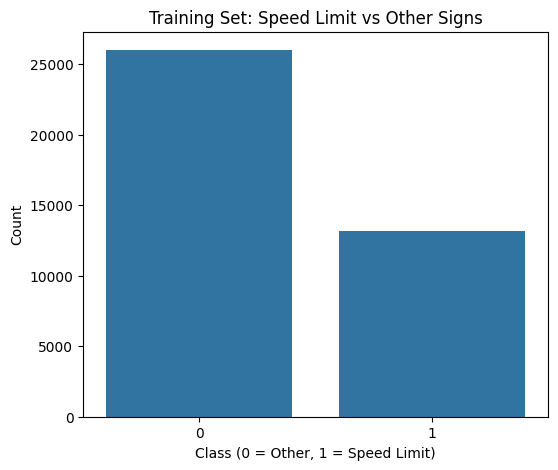

Other signs: 26009 (66.3%)
Speed limit signs: 13200 (33.7%)


In [5]:
plt.figure(figsize=(6,5))
sns.countplot(x="binary_label", data=train_df)
plt.title("Training Set: Speed Limit vs Other Signs")
plt.xlabel("Class (0 = Other, 1 = Speed Limit)")
plt.ylabel("Count")
plt.show()

counts = train_df["binary_label"].value_counts()
print(f"Other signs: {counts[0]} ({counts[0]/len(train_df)*100:.1f}%)")
print(f"Speed limit signs: {counts[1]} ({counts[1]/len(train_df)*100:.1f}%)")

## Metadata Plot: Full 43-Class Distributionn

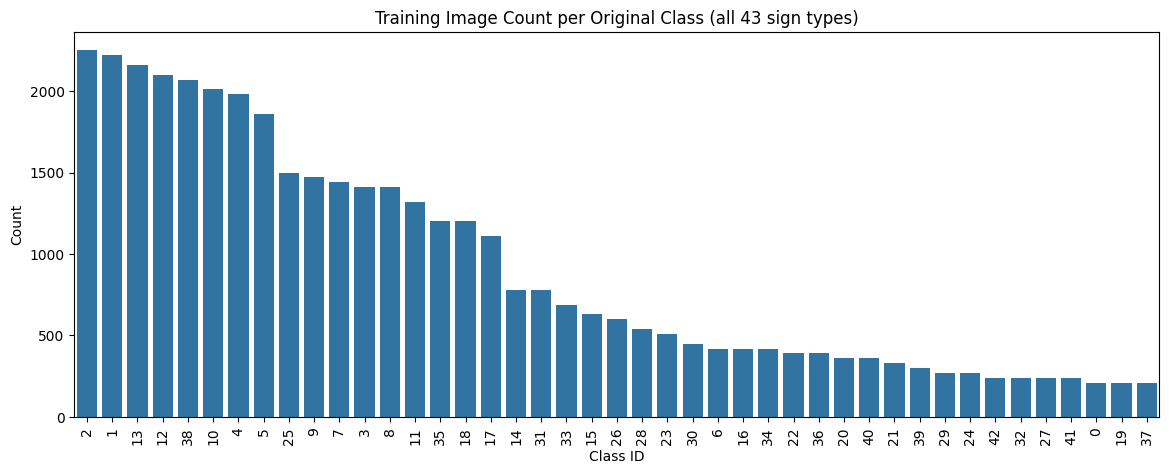

In [6]:
plt.figure(figsize=(14,5))
sns.countplot(x="ClassId", data=train_df, order=train_df["ClassId"].value_counts().index)
plt.title("Training Image Count per Original Class (all 43 sign types)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

## Metadata Plot: Image Size Distribution

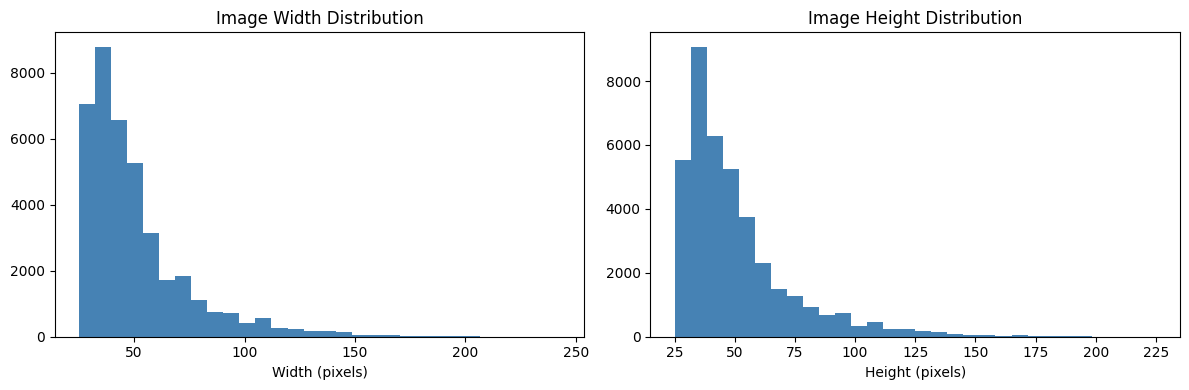

              Width        Height
count  39209.000000  39209.000000
mean      50.835880     50.328930
std       24.306933     23.115423
min       25.000000     25.000000
25%       35.000000     35.000000
50%       43.000000     43.000000
75%       58.000000     58.000000
max      243.000000    225.000000


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(train_df["Width"], bins=30, color="steelblue")
axes[0].set_title("Image Width Distribution")
axes[0].set_xlabel("Width (pixels)")

axes[1].hist(train_df["Height"], bins=30, color="steelblue")
axes[1].set_title("Image Height Distribution")
axes[1].set_xlabel("Height (pixels)")

plt.tight_layout()
plt.show()

print(train_df[["Width","Height"]].describe())

## Sample Images from Each Binary Class

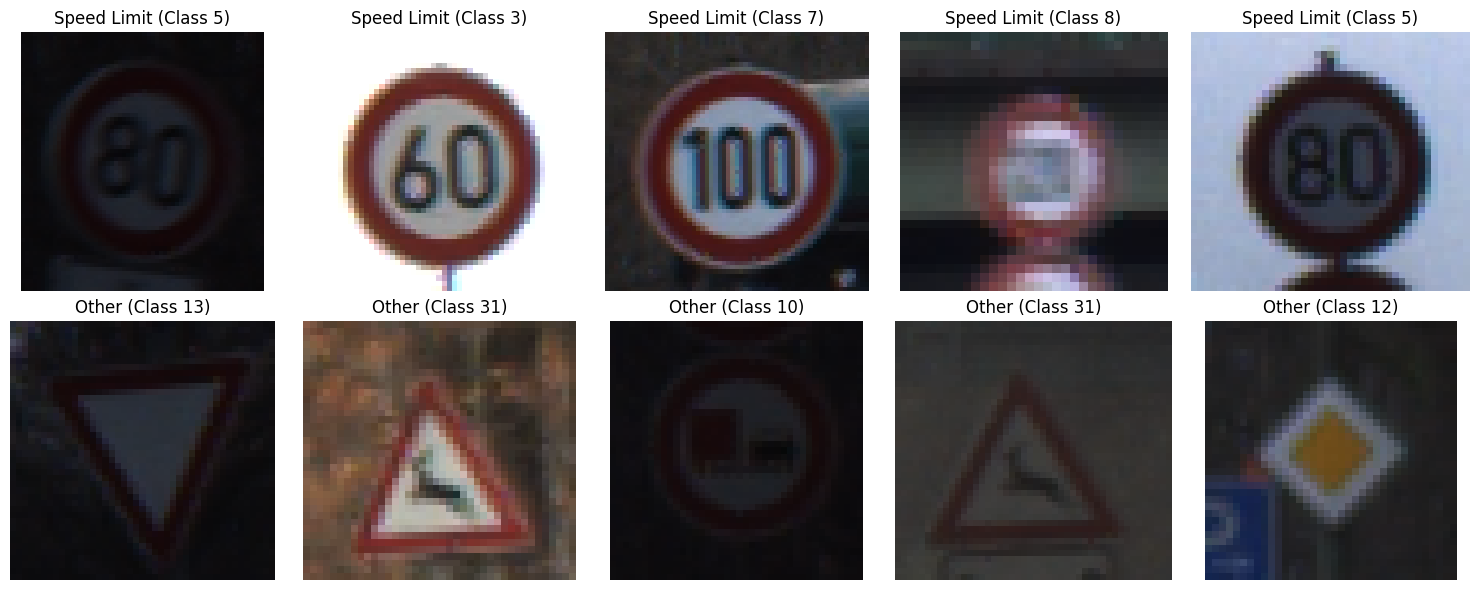

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(15,6))

speed_samples = train_df[train_df["binary_label"] == 1].sample(5, random_state=1)
other_samples = train_df[train_df["binary_label"] == 0].sample(5, random_state=1)

for ax, (_, row) in zip(axes[0], speed_samples.iterrows()):
    img = cv2.cvtColor(cv2.imread(os.path.join("gtsrb_data", row["Path"])), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"Speed Limit (Class {row['ClassId']})")
    ax.axis("off")

for ax, (_, row) in zip(axes[1], other_samples.iterrows()):
    img = cv2.cvtColor(cv2.imread(os.path.join("gtsrb_data", row["Path"])), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"Other (Class {row['ClassId']})")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Load & Resize Images (Binary Labels)

In [9]:
IMG_SIZE = 64

def load_images(df, base_dir):
    images = []
    labels = []
    for _, row in df.iterrows():
        img_path = os.path.join(base_dir, row["Path"])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(row["binary_label"])
    return np.array(images), np.array(labels)

X_train_full, y_train_full = load_images(train_df, "gtsrb_data")
X_test, y_test = load_images(test_df, "gtsrb_data")

print(X_train_full.shape, X_test.shape)

(39209, 64, 64, 3) (12630, 64, 64, 3)


## Normalize and Split

In [10]:
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (33327, 64, 64, 3) Val: (5882, 64, 64, 3) Test: (12630, 64, 64, 3)


## Simple Binary CNN

In [11]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,281 (6.20 MB)

 Trainable params: 1,625,281 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

## Training

In [12]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9517 - loss: 0.1213 - val_accuracy: 0.9952 - val_loss: 0.0203
Epoch 2/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9925 - loss: 0.0261 - val_accuracy: 0.9976 - val_loss: 0.0147
Epoch 3/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9950 - loss: 0.0161 - val_accuracy: 0.9978 - val_loss: 0.0110
Epoch 4/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9972 - loss: 0.0097 - val_accuracy: 0.9978 - val_loss: 0.0099
Epoch 5/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9970 - loss: 0.0104 - val_accuracy: 0.9976 - val_loss: 0.0112
Epoch 6/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9974 - loss: 0.0084 - val_accuracy: 0.9980 - val_loss: 0.0084
Epoch 7/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9978 - loss: 0.0071 - val_accuracy: 0.9986 - val_loss: 0.0063
Epoch 8/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9983 - loss: 0.0056 - val_acc

## Model Evaluation

In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=["Other", "Speed Limit"]))

395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9934 - loss: 0.0404
Test Accuracy: 0.9934
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
              precision    recall  f1-score   support

       Other       0.99      1.00      1.00      8310
 Speed Limit       1.00      0.99      0.99      4320

    accuracy                           0.99     12630
   macro avg       0.99      0.99      0.99     12630
weighted avg       0.99      0.99      0.99     12630



## Confusion Matrix

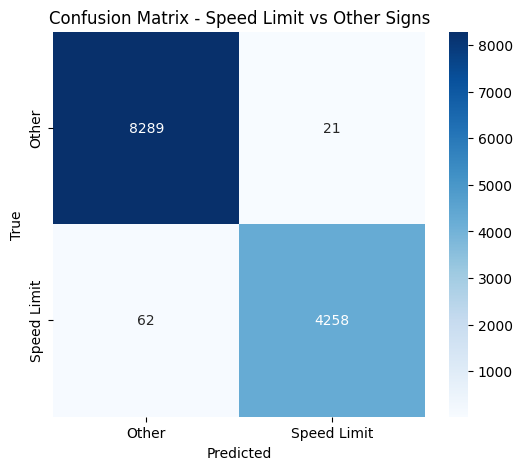

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Other","Speed Limit"], yticklabels=["Other","Speed Limit"])
plt.title("Confusion Matrix - Speed Limit vs Other Signs")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()